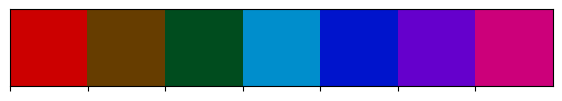

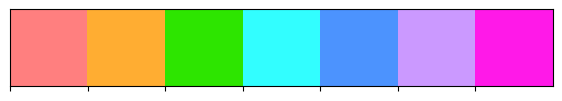

In [1]:
import os
import sys
import torch
import numpy as np
import scipy
import gymnasium as gym
import random
import matplotlib.pylab as plt

SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.policy_analysis import discount_episode_reward, sum_ep_timesteps, set_blind_colors
light_colors, dark_colors = set_blind_colors()
dark_colors += ["y", "gold", "silver", "black", "orange", "gray", "navy", "rosybrown", "lightcyan", "hotpink"]

In [2]:
def confidence_interval(data, confidence=0.95):
    conf = scipy.stats.sem(data) * scipy.stats.t.ppf((1 + confidence) / 2, len(data) - 1)
    return conf

def confidence_interval_2d(data: np.ndarray, confidence: float=0.95):
    confds = []
    for j in range(data.shape[1]):
        k = confidence_interval(data[:, j])
        confds.append(k)
    return np.array(confds)

def get_train_data(dir: str, n_seeds: int = 10, gamma: float = 0.99, ep_window: int =10, save_data: bool = False):
    max_x_axis = 0
    seeds_y_axis = []
    for seed in range(n_seeds):
        train_reward = np.load(dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
        ep_reward, ep_length = discount_episode_reward(train_reward, gamma=gamma)
        ep_timesteps_sum = sum_ep_timesteps(ep_length) 
        x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
        max_x_axis = np.max(x_axis) if np.max(x_axis) > max_x_axis else max_x_axis
        y_axis = []
        for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
            ind = np.where(ep_timesteps_sum > timestep)[0][0]
            value = np.mean(ep_reward[ind - ep_window: ind]) if ind > ep_window else ep_reward[ind]
            y_axis.append(value)
        seeds_y_axis.append(y_axis)
    lenghts = [len(l) for l in seeds_y_axis]
    cut_data = np.array([l[:min(lenghts)] for l in seeds_y_axis])
    conf_train = confidence_interval_2d(cut_data)
    if save_data:
        np.save(dir + "/reward_train_all.npy", {"seeds_y_axis" :seeds_y_axis})
        np.save(dir + "/reward_train_mean", np.mean(cut_data, 0))
        np.save(dir + "/reward_train_std", np.std(cut_data, 0))
        np.save(dir + "/reward_train_confidence", conf_train)
    return seeds_y_axis, np.mean(cut_data, 0), np.std(cut_data, 0), conf_train

In [3]:
grid_size = [10, 10]
n_seeds = 10
dryness = 0.05
gamma = 0.99
ep_window = 11
q_lr = 0.0001
r_lr = 0.0001
n_mdp_action = 6

device = "mps:0"
timesteps_freq = int(5e5)
n_rows, n_colums = grid_size

## Baselines

In [ ]:
eps = {0.0001: r"$\epsilon$ decay=$10^{-4}$", 1e-05: r"$\epsilon$ decay=$10^{-5}$", 1e-06: r"$\epsilon$ decay=$10^{-6}$",
       1e-07: r"$\epsilon$ decay=$10^{-7}$"}
# eps = {0.0001: r"$\epsilon$ decay=$10^{-4}$"}
for ep in eps:
    fig = plt.figure(figsize=(6, 4))
    count = 0
    # for base in ["reward_model", "zero_reward", "ignore"]:
    for base in ["zero_reward"]:
        main_dir = "../general_models/Plants/{}/{}_{}_channel/dry_{}/window_{}/eps_decay_{}".format(base, n_rows, n_colums, dryness, ep_window, ep)
        log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(0.0001, 0.0001)
        seed_train, mean_train, _, conf_train = get_train_data(log_dir, n_seeds, save_data=True)
        for seed_tr in seed_train:
            plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
        plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label=base)
        plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
        count += 1
    
    
    plt.xlabel(r"Training Timesteps", fontsize=18)
    plt.ylabel("Discounted Joint Reward", fontsize=18)
    # plt.xticks(np.arange(0, len(seed_tr) + 2, 2) * timesteps_freq, np.arange(0, len(seed_tr) + 2, 2), fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(axis="y")
    # plt.legend(fontsize=12)
    plt.tight_layout()
    # fig.savefig(main_dir + "/binary_training_curve_indv_run_confidence.pdf", dpi=300)
    # fig.savefig("../general_models/Plants/binary_training_curve_indv_run_no_legend.pdf", dpi=300)
    

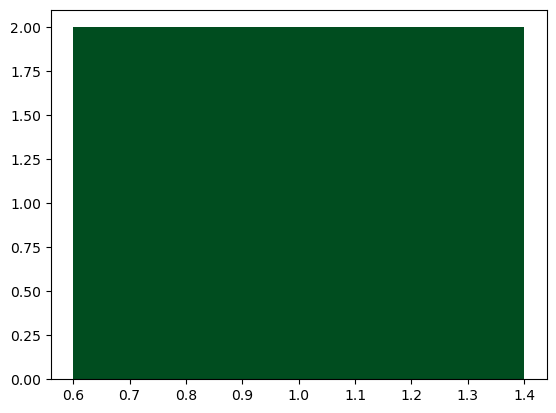

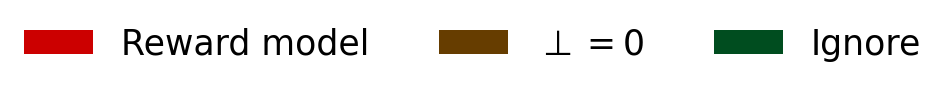

In [2]:
legends = ["Reward model", r"$\bot = 0$", "Ignore"]
f = lambda m,c: plt.bar(1,2, color=c)[0]
handles = [f("s", dark_colors[i]) for i in range(3)]
fig = plt.figure(figsize=(9.4, 1))
fig.legend(handles, legends, fontsize=25, ncol=3, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# fig.savefig("../general_models/Plants/reward_model/10_10_channel/dry_0.05/window_11/baselines_legend.pdf", dpi=300,)

## hyper-paramters tunning

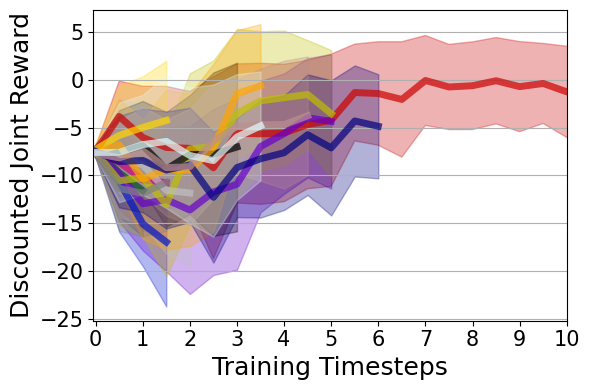

In [5]:
timestep_clip = int(10e6)
r_lrs = [0.0001, 0.0005, 0.001, 0.005]
q_lrs = [0.0001, 0.0005, 0.001, 0.005]
labels = {0.001: r"$10^{-3}$", 0.005: r"$5*10^{-3}$", 0.0001: r"$10^{-4}$", 0.0005: r"$5*10^{-4}$"}
fig = plt.figure(figsize=(6, 4))
count = 0
for q_lr in q_lrs:
    for r_lr in r_lrs:
        main_dir = "../general_models/Plants/ignore/{}_{}_channel/dry_{}/window_{}/eps_decay_0.0001".format(n_rows, n_colums, dryness, ep_window)
        log_dir = main_dir + "/q_lr_{}/reward_lr_{}/".format(q_lr, r_lr)
        legend = r"Q={}, R={}".format(labels[q_lr], labels[r_lr])
        _, mean_train, _, conf_train = get_train_data(log_dir, n_seeds, save_data=True)
        # for seed_tr in seed_train:
            # plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
        plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label=legend)
        plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
        count += 1

plt.xlabel("Training Timesteps", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)
x_legend = np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq) / 1e6
plt.xticks(np.arange(0, timestep_clip + 1e6, 2 * timesteps_freq), x_legend.astype(int), fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis="y")
plt.xlim(-50000, timestep_clip)
plt.tight_layout()
# fig.savefig(main_dir + "/paramters_tunning_training_curve_no_legend.pdf", dpi=300)

## Legend

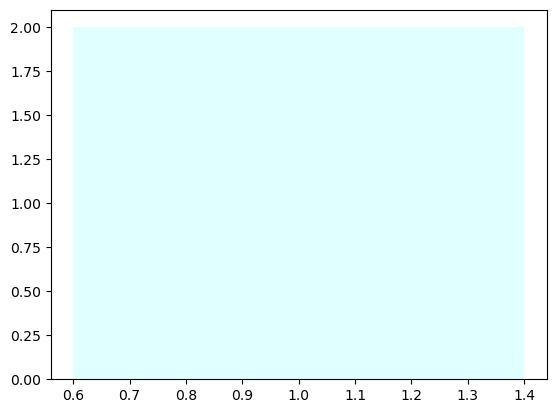

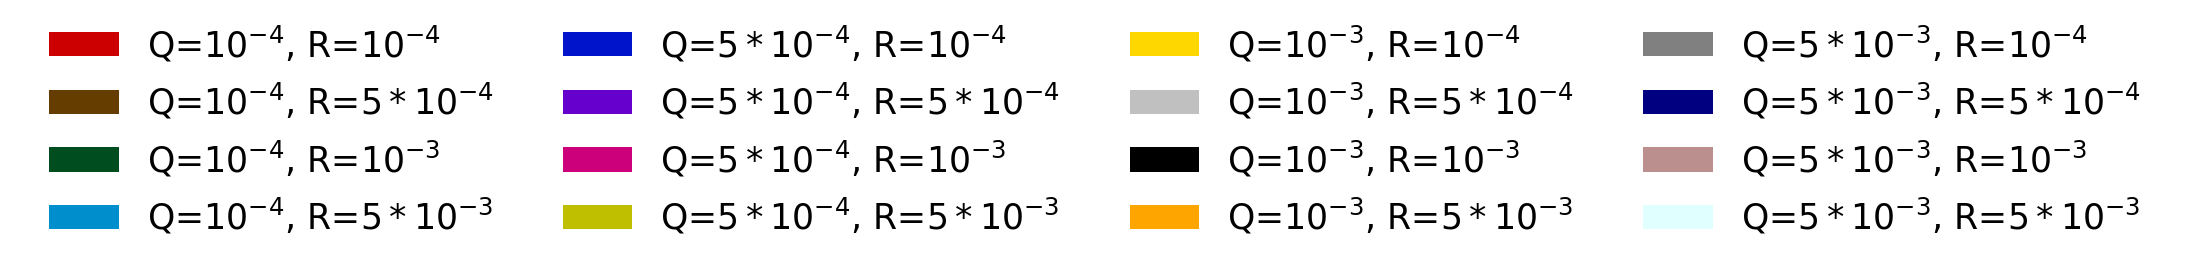

In [5]:
legends = []
for q_lr in q_lrs:
    for r_lr in r_lrs:
        legends.append(r"Q={}, R={}".format(labels[q_lr], labels[r_lr]))
f = lambda m,c: plt.bar(1,2, color=c)[0]
handles = [f("s", dark_colors[i]) for i in range(16)]
fig = plt.figure(figsize=(22, 2.5))
fig.legend(handles, legends, fontsize=25, ncol=4, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
fig.savefig(main_dir + "/paramters_tun_legend.pdf", dpi=300,)

## $\epsilon$ decay tunnig

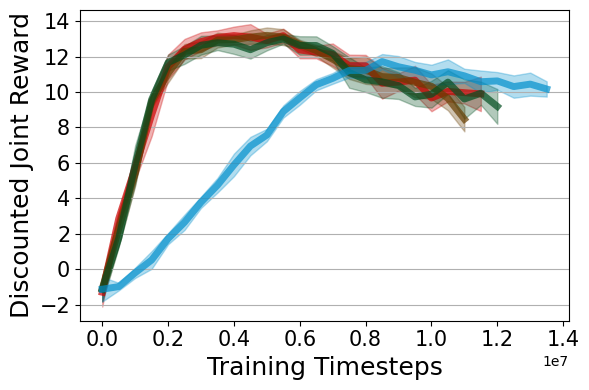

In [11]:
eps = {0.0001: r"$\epsilon$ decay=$10^{-4}$", 1e-05: r"$\epsilon$ decay=$10^{-5}$", 1e-06: r"$\epsilon$ decay=$10^{-6}$", 1e-07: r"$\epsilon$ decay=$10^{-7}$"}
# eps = {0.0001: r"$\epsilon$ decay=$10^{-4}$", 1e-05: r"$\epsilon$ decay=$10^{-5}$", 1e-06: r"$\epsilon$ decay=$10^{-6}$"}
fig = plt.figure(figsize=(6, 4))
count = 0
for ep in eps:
    main_dir = "../general_models/Plants/ignore/{}_{}_channel/dry_{}/room/window_{}/".format(n_rows, n_colums, dryness, ep_window)
    log_dir = main_dir + "eps_decay_{}/q_lr_{}/reward_lr_{}/".format(ep, 0.0001, 0.0001)
    _, mean_train, _, conf_train = get_train_data(log_dir, n_seeds, save_data=True)
    # for seed_tr in seed_train:
        # plt.plot(np.arange(len(seed_tr)) * timesteps_freq, seed_tr, lw=0.5,  c=dark_colors[count])
    plt.plot(np.arange(len(mean_train)) * timesteps_freq, mean_train, lw=5,  c=dark_colors[count], alpha=0.7, label=eps[ep])
    plt.fill_between(np.arange(len(mean_train)) * timesteps_freq, mean_train - conf_train, mean_train + conf_train, color=dark_colors[count], alpha=0.3)
    count += 1

plt.xlabel("Training Timesteps", fontsize=18)
plt.ylabel("Discounted Joint Reward", fontsize=18)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(axis="y")
# plt.legend(fontsize=12)#fontsize=12
plt.tight_layout()
fig.savefig(main_dir + "/room_eps_decay_paramters_tunning_training_curve_no_legend.pdf", dpi=300)

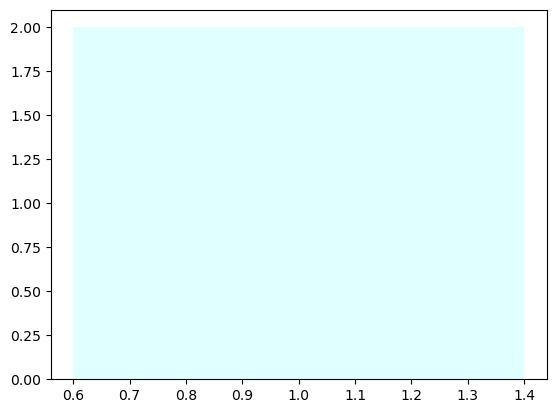

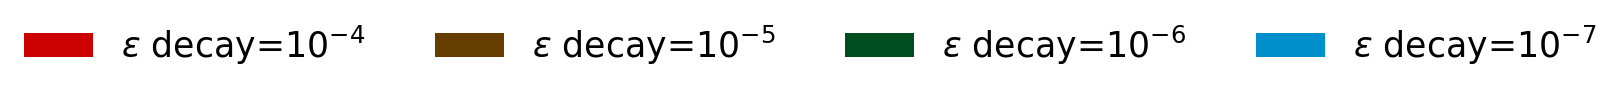

In [19]:
eps_legends = []
for ep in eps:
    eps_legends.append(eps[ep])
f = lambda m,c: plt.bar(1,2, color=c)[0]
handles = [f("s", dark_colors[i]) for i in range(16)]
fig = plt.figure(figsize=(16, 1))
fig.legend(handles, eps_legends, fontsize=25, ncol=4, loc='center', frameon=False)
fig.gca().set_axis_off()
plt.tight_layout()
# fig.savefig(main_dir + "/binary_eps_decay_paramters_tun_legend.pdf", dpi=300,)

## test env

In [3]:
from src.wrappers.env_wrappers import WallObs, WindowViewObs, MultiChannel
from src.wrappers.monitor_wrappers import RoomMonitor, BinaryMonitor

In [4]:
def select_action(q_values) -> int:
    """Choose an action from a Q value distribution/ break ties to a random action"""
    indices = np.argwhere(q_values == np.max(q_values))
    return random.choice(indices)[0]

In [21]:
env_id = "gym_monitor/Plants-Watering-v1"

plants_env = gym.make(
    env_id,
    grid_size=grid_size,
    n_plants=8,
    plants_dryness_prob=dryness,
    dry_difference=0.5,
    agent_start_pos=None,
    max_episode_steps=100,
    render_mode = "human",
    add_new_plants=False,
    add_more_plants=True,
    )

wall_env = WallObs(plants_env, grid_size=grid_size, n_walls=10)
window_env = WindowViewObs(wall_env, window_size=ep_window)
channel_env = MultiChannel(window_env, normalize_obs=True)
# env = BinaryMonitor(channel_env, full_monitor=False, monitor_cost=0.2, monitor_reset_prob=0.0)
env = RoomMonitor(channel_env, full_monitor=False, monitor_cost=0.0, monitor_column_ind=5)

In [22]:
dir = "../general_models/Plants/zero_reward/{}_{}_channel/dry_{}/cacti_room/window_11/q_lr_0.0001/reward_lr_0.0001/".format(n_rows, n_colums, dryness)
q_model = torch.load(dir + "q_network_{}".format(7), map_location=torch.device(device))

In [ ]:
ep_reward = []
for i in range(1):
    s, _ = env.reset()
    total_r, timestep, spill, cactus, water_plant = 0, 0, 0, 0, 0
    ask_monitor = 0
    done = False
    actions, mdp_s, mon_s = [], [], []
    cactus_obs, plants_obs = [], []
    action_probs = []
    env.render()
    while timestep < 100:
        
        mdp_obs = torch.tensor(s["mdp"], dtype=torch.float32, device=device).unsqueeze(0)
        mon_obs = torch.tensor([s["monitor"]], dtype=torch.float32, device=device).unsqueeze(0)
        mdp_s.append(mdp_obs)
        mon_s.append(mon_obs)

        with torch.no_grad():
            # q_values = q_model(mdp_obs)
            q_values = q_model[5:](torch.concat((q_model[:5](mdp_obs), mon_obs), 1))
        action = select_action(q_values.cpu().numpy().squeeze())
        
        actions.append(action)
        plant = env.get_grid()[1, env.get_agent_pos()[0], env.get_agent_pos()[1]]
        if plant == 0.5:
            cactus_obs.append(mdp_obs)
        if plant == 1:
            plants_obs.append(mdp_obs)
        s, r, done, _, info = env.step({"mdp": action, "monitor": 0})
        # s, r, done, _, info = env.step({"mdp": action % n_mdp_action, "monitor": action // n_mdp_action})
        if action == 4:
            if plant == 0.0:  # spill water in the floor
                spill += 1
            if plant == 0.5: # water cactus
                cactus += 1
                print("r", info["mdp_reward"])
            else:
                water_plant += 1
                # print("monitor", action // n_mdp_action)
        reward = info["mdp_reward"] + r["monitor"]
        total_r += reward * (gamma**timestep)
        # if action // n_mdp_action == 1:
        #     ask_monitor += 1
        timestep += 1
        env.render()
    ep_reward.append(total_r)
    print("spill", spill)
    print("cactus", cactus)
    print("water_plant", water_plant)
    print("monitor", ask_monitor)
actions = np.squeeze(actions)
# env.close()

In [8]:
env.get_new_plants_pos(), env.get_plants_pos()

(array([[0, 6],
        [9, 8],
        [6, 7],
        [7, 7]]),
 array([[3, 2],
        [3, 4],
        [2, 2],
        [4, 3],
        [9, 6],
        [3, 6],
        [1, 8],
        [7, 6]]))